In [6]:
import sys
sys.path.append('/home/iago/ChIRo/')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch_geometric
from torch_geometric.nn.resolver import swish

from scipy.optimize import curve_fit

from tqdm import tqdm
from copy import deepcopy
import json

from model.params_interpreter import string_to_object 
from model.alpha_encoder import Encoder

from model.gnn_3D.schnet import SchNet
# from model.gnn_3D.dimenet_pp import DimeNetPlusPlus
from model.gnn_3D.spherenet import SphereNet

from model.train_functions import classification_loop_alpha
from model.train_functions import evaluate_classification_loop_alpha
from model.gnn_3D.train_functions import classification_loop
from model.gnn_3D.train_functions import evaluate_classification_loop

from model.datasets_samplers import Dataset_3D_GNN, MaskedGraphDataset, StereoBatchSampler, SiameseBatchSampler, Sample_Map_To_Positives, Sample_Map_To_Negatives, NegativeBatchSampler, SingleConformerBatchSampler


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [34]:
def get_accuracy_ChIRo(path_to_results = None, path_to_params_file = None, path_to_model_dict = None, RSA_class: int = -1):
    try:
        results_df = pd.read_csv(str(path_to_results))
        if RSA_class != -1:
            results_df = results_df[results_df['RSA_class'] == RSA_class]
            
    except:
        print('creating model...')
        best_state_dict = str(path_to_model_dict)

        with open(path_to_params_file) as f: # should contain path to params.json file
            params = json.load(f)
        
        layers_dict = deepcopy(params['layers_dict'])
        
        activation_dict = deepcopy(params['activation_dict'])
        for key, value in params['activation_dict'].items(): 
            activation_dict[key] = string_to_object[value] # convert strings to actual python objects/functions using pre-defined mapping
        
        activation_dict['output_mlp_output_activation'] = torch.nn.Softmax(dim=1)
        num_node_features = 52
        num_edge_features = 14
        
        model = Encoder(
            F_z_list = params['F_z_list'], # dimension of latent space
            F_H = params['F_H'], # dimension of final node embeddings, after EConv and GAT layers
            F_H_embed = num_node_features, # dimension of initial node feature vector, currently 41
            F_E_embed = num_edge_features, # dimension of initial edge feature vector, currently 12
            F_H_EConv = params['F_H_EConv'], # dimension of node embedding after EConv layer
            layers_dict = layers_dict,
            activation_dict = activation_dict,
            GAT_N_heads = params['GAT_N_heads'],
            chiral_message_passing = params['chiral_message_passing'],
            CMP_EConv_MLP_hidden_sizes = params['CMP_EConv_MLP_hidden_sizes'],
            CMP_GAT_N_layers = params['CMP_GAT_N_layers'],
            CMP_GAT_N_heads = params['CMP_GAT_N_heads'],
            c_coefficient_normalization = params['c_coefficient_normalization'], # None, or one of ['sigmoid','softmax']
            sinusoidal_shift = params['sinusoidal_shift'], # true or false
            encoder_reduction = params['encoder_reduction'], #mean or sum
            output_concatenation_mode = params['output_concatenation_mode'], # none (if contrastive), conformer, molecule, or z_alpha (if regression)
            EConv_bias = params['EConv_bias'], 
            GAT_bias = params['GAT_bias'], 
            encoder_biases = params['encoder_biases'], 
            dropout = params['dropout'], # applied to hidden layers (not input/output layer) of Encoder MLPs, hidden layers (not input/output layer) of EConv MLP, and all GAT layers (using their dropout parameter)
            is_binary=False
            )
        
        model.load_state_dict(torch.load(best_state_dict, map_location=next(model.parameters()).device), strict=True)
        model.to(device)
        
        test_dataframe = pd.read_pickle(params['test_datafile'])        
        test_dataset = MaskedGraphDataset(test_dataframe, 
                                            regression = 'RS_label_binary', # top_score,  RS_label_binary, sign_rotation
                                            stereoMask = params['stereoMask'],
                                            mask_coordinates = params['mask_coordinates'], 
                                            )
        test_loader = torch_geometric.data.DataLoader(test_dataset, num_workers = 0, batch_size = 1, shuffle = False)
        
        targets, outputs = evaluate_classification_loop_alpha(model, test_loader, device, batch_size = 1, dataset_size = len(test_dataset), is_binary=False)
        
        results_df = deepcopy(test_dataframe[['ID', 'SMILES_nostereo', 'RS_label_binary']])
        results_df['targets'] = targets
        results_df['outputs'] = outputs
    
    y = torch.tensor(np.array(results_df.targets))
    output = torch.tensor(np.array(results_df.outputs))
    
    acc = 1.0 - (torch.sum(torch.abs(y.squeeze().detach() - output.squeeze().detach())) / y.shape[0])
    
    return results_df, float(acc)

In [95]:
def get_accuracy_spherenet(path_to_results = None, path_to_params_file = None, path_to_model_dict = None, RSA_class = -1):
    try:
        results_df = pd.read_csv(str(path_to_results))
        if RSA_class != -1:
            results_df = results_df[results_df['RSA_class'] == RSA_class]
            
    except:
        print('creating model...')
        params_file = str(path_to_params_file)
        best_state_dict = str(path_to_model_dict)

        with open(params_file) as f: # should contain path to params.json file
            params = json.load(f)
        
        model = SphereNet(
                    energy_and_force = False, 
                    cutoff = params['cutoff'],
                    num_layers = params['num_layers'], 
                    hidden_channels = params['hidden_channels'],
                    out_channels = params['out_channels'], 
                    int_emb_size = params['int_emb_size'],
                    basis_emb_size_dist = params['basis_emb_size_dist'],
                    basis_emb_size_angle = params['basis_emb_size_angle'], 
                    basis_emb_size_torsion = params['basis_emb_size_torsion'],
                    out_emb_channels = params['out_emb_channels'], 
                    num_spherical = params['num_spherical'],
                    num_radial = params['num_radial'],
                    envelope_exponent = params['envelope_exponent'],
                    num_before_skip = params['num_before_skip'],
                    num_after_skip = params['num_after_skip'], 
                    num_output_layers = params['num_output_layers'],
                    act=swish, 
                    output_init='GlorotOrthogonal', 
                    use_node_features = True,
                    MLP_hidden_sizes = params['MLP_hidden_sizes'], # [] for contrastive
                    is_binary=True
            )
        
        model.load_state_dict(torch.load(best_state_dict, map_location=next(model.parameters()).device), strict=True)
        model.to(device)
        
        full_test_dataframe = pd.read_pickle(params['test_datafile'])        
        test_dataframe = full_test_dataframe # [full_test_dataframe.ID.isin(missing_IDs)]
        
        test_dataset = Dataset_3D_GNN(test_dataframe, 
                                    regression = 'RSA_class', # sign_rotation, top_score, score, score_range_binary, relative_score_range_binary, RS_label_binary
                                    getDataFrom = params['getDataFrom'], #'source' or 'mol'
                                    rotate_augmentation = params['rotate_augmentation'], # range from 0.0 to 360.0
                            )
        
        test_loader = torch_geometric.data.DataLoader(test_dataset, num_workers = 0, batch_size = 1, shuffle = False)
        
        targets, outputs = evaluate_classification_loop(model, test_loader, device, batch_size = 1, dataset_size = len(test_dataset))
        
        results_df = deepcopy(test_dataframe[['ID', 'SMILES_nostereo', 'RSA_class']])
        results_df['targets'] = targets
        results_df['outputs'] = outputs
    
    y = torch.tensor(np.array(results_df.targets))
    output = torch.tensor(np.array(results_df.outputs)) + 2
    # print (y.squeeze, output)
    print (y.shape[0])
    print (y, output)
    print (torch.abs(y - output).shape[0])
    i = 0
    for row_y, row_output in zip(y, output):
        i += 1 if row_y != row_output else 0
    acc = 1.0 - (i / y.shape[0])
    # acc = 1.0 - (torch.sum(torch.abs(y.squeeze().detach() - torch.round(torch.sigmoid(output.squeeze().detach())))) / y.shape[0])
    
    return results_df, float(acc)

In [85]:
# ChIRo
results_df, accuracy_RSA = get_accuracy_ChIRo(
    path_to_results = '../results_RSA_chiro/best_model_test_results.csv',
    path_to_params_file = '../params_files/params_RSA_ChIRo.json',
    path_to_model_dict = '../results_RSA_chiro/best_model.pt',
)
results_df_R, accuracy_R = get_accuracy_ChIRo(
    path_to_results = '../results_RSA_chiro/best_model_test_results.csv',
    path_to_params_file = '../params_files/params_RSA_ChIRo.json',
    path_to_model_dict = '../results_RSA_chiro/best_model.pt',
    RSA_class=0
)
results_df_S, accuracy_S = get_accuracy_ChIRo(
    path_to_results = '../results_RSA_chiro/best_model_test_results.csv',
    path_to_params_file = '../params_files/params_RSA_ChIRo.json',
    path_to_model_dict = '../results_RSA_chiro/best_model.pt',
    RSA_class=1
)
results_df_A, accuracy_A = get_accuracy_ChIRo(
    path_to_results = '../results_RSA_chiro/best_model_test_results.csv',
    path_to_params_file = '../params_files/params_RSA_ChIRo.json',
    path_to_model_dict = '../results_RSA_chiro/best_model.pt',
    RSA_class=2
)


15054


IndexError: tuple index out of range

In [82]:
print ('RSA acc\tR acc\tS\tA acc')
print (f'{accuracy_RSA}\t{accuracy_R}\t{accuracy_S}\t{accuracy_A}')

RSA acc	R acc	S	A acc
0.26564368274212835	0.8915614351573462	-0.0628166160081054	-0.02709551656920084


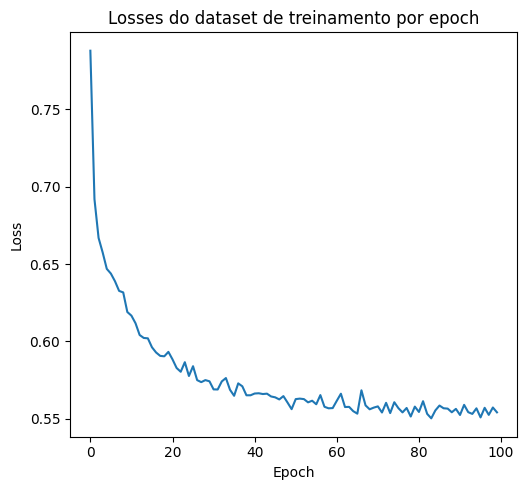

In [75]:
import matplotlib.pyplot as plt


losses = torch.load('../results_RSA_chiro/train_epoch_losses.pt')
plt.figure(figsize=(10, 5))

# Histogram for 'Column1'
plt.subplot(1, 2, 1)  # 1 row, 2 columns, 1st subplot
plt.plot(losses)
plt.title('Losses do dataset de treinamento por epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')

# plt.xticks(np.arange(0, max(total_dataset['num_atoms']), 5))

# Show the plot
plt.tight_layout()
plt.show()

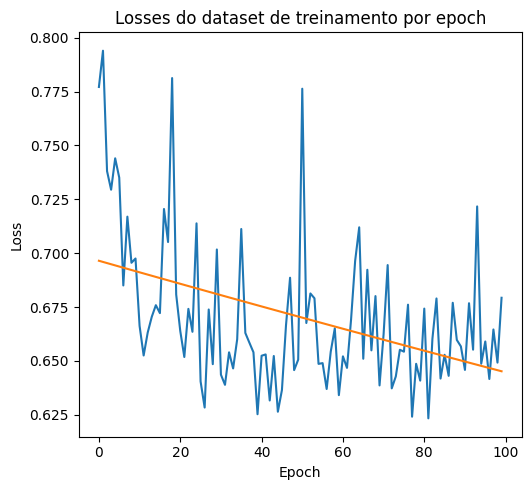

In [79]:
import matplotlib.pyplot as plt


losses = torch.load('../results_RSA_chiro/val_epoch_losses.pt')
plt.figure(figsize=(10, 5))

# Função para ajuste exponencial
def exponential_func(x, a, b):
    return a * np.exp(b * x)

# Histogram for 'Column1'
plt.subplot(1, 2, 1)  # 1 row, 2 columns, 1st subplot
plt.plot(losses)
plt.title('Losses do dataset de treinamento por epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')

params, params_covariance = curve_fit(exponential_func, np.linspace(0, 1, 100), losses, p0=[1, 0.1])
y_fit = exponential_func(np.linspace(0, 1, 100), *params)
plt.plot(y_fit)
# plt.xticks(np.arange(0, max(total_dataset['num_atoms']), 5))

# Show the plot
plt.tight_layout()
plt.show()

In [96]:
# spherenet
results_df_chiro_spherenet, accuracy_RSA_chiro_spherenet = get_accuracy_spherenet(
    path_to_results = '../results_RSA_spherenet/best_model_test_results.csv',
    path_to_params_file = '../results_RSA_spherenet/params_RSA_spherenet.json',
    path_to_model_dict = '../results_RSA_spherenet/best_model.pt'
)
results_df_chiro_spherenet_R, accuracy_RSA_chiro_spherenet_R = get_accuracy_spherenet(
    path_to_results = '../results_RSA_spherenet/best_model_test_results.csv',
    path_to_params_file = '../results_RSA_spherenet/params_RSA_spherenet.json',
    path_to_model_dict = '../results_RSA_spherenet/best_model.pt',
    RSA_class=0
)
results_df_chiro_spherenet_S, accuracy_RSA_chiro_spherenet_S = get_accuracy_spherenet(
    path_to_results = '../results_RSA_spherenet/best_model_test_results.csv',
    path_to_params_file = '../results_RSA_spherenet/params_RSA_spherenet.json',
    path_to_model_dict = '../results_RSA_spherenet/best_model.pt',
    RSA_class=1
)
results_df_chiro_spherenet_A, accuracy_RSA_chiro_spherenet_A = get_accuracy_spherenet(
    path_to_results = '../results_RSA_spherenet/best_model_test_results.csv',
    path_to_params_file = '../results_RSA_spherenet/params_RSA_spherenet.json',
    path_to_model_dict = '../results_RSA_spherenet/best_model.pt',
    RSA_class=2
)

15054
tensor([2., 2., 2.,  ..., 2., 2., 2.], dtype=torch.float64) tensor([3, 3, 3,  ..., 3, 3, 1])
15054
4989
tensor([0., 0., 0.,  ..., 0., 0., 0.], dtype=torch.float64) tensor([3, 3, 3,  ..., 1, 1, 1])
4989
4935
tensor([1., 1., 1.,  ..., 1., 1., 1.], dtype=torch.float64) tensor([3, 3, 3,  ..., 1, 1, 1])
4935
5130
tensor([2., 2., 2.,  ..., 2., 2., 2.], dtype=torch.float64) tensor([3, 3, 3,  ..., 3, 3, 1])
5130


In [97]:
print(accuracy_RSA_chiro_spherenet)
print(accuracy_RSA_chiro_spherenet_R)
print(accuracy_RSA_chiro_spherenet_S)
print(accuracy_RSA_chiro_spherenet_A)

0.17211372392719548
0.0
0.5250253292806484
0.0


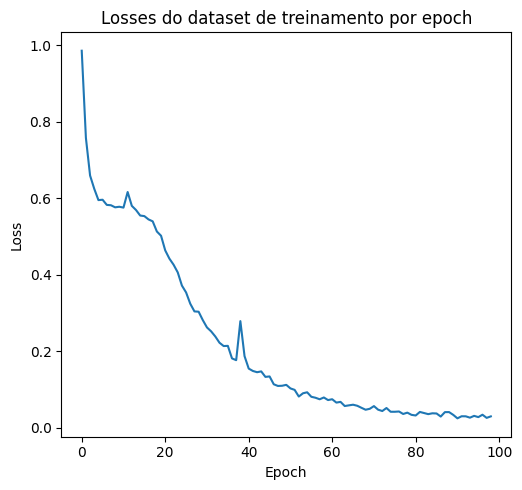

In [88]:
import matplotlib.pyplot as plt


losses = torch.load('../results_RSA_spherenet/train_epoch_losses.pt')
plt.figure(figsize=(10, 5))

# Histogram for 'Column1'
plt.subplot(1, 2, 1)  # 1 row, 2 columns, 1st subplot
# print(filter(lambda x: x > 50, losses))
plt.plot(list(filter(lambda x: x < 50, losses)))
plt.title('Losses do dataset de treinamento por epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')

# plt.xticks(np.arange(0, max(total_dataset['num_atoms']), 5))

# Show the plot
plt.tight_layout()
plt.show()

ValueError: array must not contain infs or NaNs

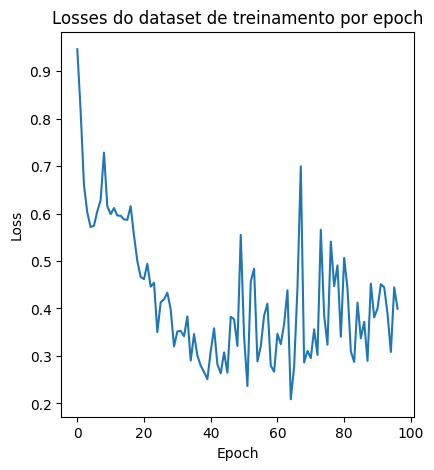

In [66]:
import matplotlib.pyplot as plt


losses = torch.load('../results_RSA_spherenet/val_epoch_losses.pt')
plt.figure(figsize=(10, 5))

# Função para ajuste exponencial
def exponential_func(x, a, b):
    return a * np.exp(b * x)

# Histogram for 'Column1'
plt.subplot(1, 2, 1)  # 1 row, 2 columns, 1st subplot
plt.plot(list(filter(lambda x: x < 50, losses)))
plt.title('Losses do dataset de treinamento por epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')

params, params_covariance = curve_fit(exponential_func, np.linspace(0, 1, 100), losses, p0=[1, 0.1])
y_fit = exponential_func(np.linspace(0, 1, 100), *params)
plt.plot(y_fit)
# plt.xticks(np.arange(0, max(total_dataset['num_atoms']), 5))

# Show the plot
plt.tight_layout()
plt.show()